In [19]:
#1.data preparation
import pandas as pd
import numpy as np

#load datasets
apps=pd.read_csv("apps.csv")
reviews=pd.read_csv("user_reviews.csv")

#convert columns
apps['Rating']=pd.to_numeric(apps['Rating'],errors='coerce')
apps['Reviews']=pd.to_numeric(apps['Reviews'],errors='coerce')

#clean size
def convert_size(size):
    if 'M' in str(size):
        return float(size.replace('M',''))
    elif 'K' in str(size):
        return float(size.replace('K',''))
    else:
        return np.nan

apps['Size']=apps['Size'].apply(convert_size)

#clean installs
apps['Installs']=apps['Installs'].str.replace('[+,]','',regex=True)
apps['Installs']=pd.to_numeric(apps['Installs'],errors='coerce')

#clean price
apps['Price']=apps['Price'].astype(str)
apps['Price']=apps['Price'].str.replace('$','',regex=False)
apps['price']=pd.to_numeric(apps['Price'],errors='coerce')

#fill missing values
apps.fillna(method='ffill',inplace=True)

print("cleaned apps data")
print(apps.head())

cleaned apps data
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size  Installs  Type Price Content Rating  \
0  ART_AND_DESIGN     4.1      159   NaN     10000  Free     0       Everyone   
1  ART_AND_DESIGN     3.9      967   NaN    500000  Free     0       Everyone   
2  ART_AND_DESIGN     4.7    87510   NaN   5000000  Free     0       Everyone   
3  ART_AND_DESIGN     4.5   215644   NaN  50000000  Free     0           Teen   
4  ART_AND_DESIGN     4.3      967   NaN    100000  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               

C:\Users\vedashree k a\AppData\Local\Temp\ipykernel_15624\2252833881.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  apps.fillna(method='ffill',inplace=True)


Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
EVENTS                   64
ART_AND_DESIGN           64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64


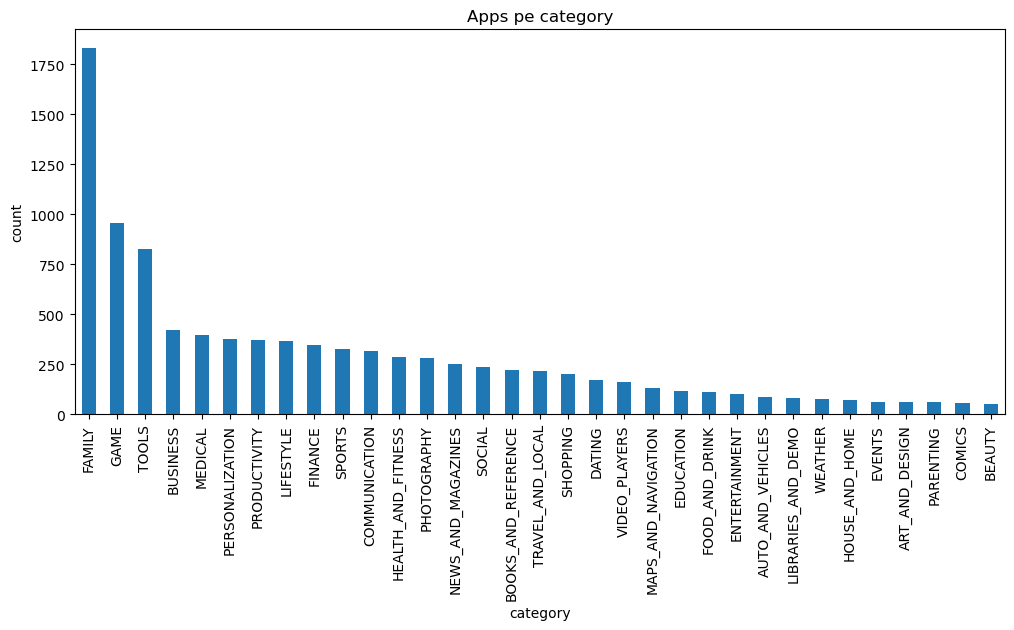

In [20]:
#2.category exploration(apps.csv)

import matplotlib.pyplot as plt
category_counts=apps['Category'].value_counts()

print(category_counts)

#bar chat
category_counts.plot(kind='bar',figsize=(12,5))
plt.title("Apps pe category")
plt.xlabel("category")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.show()

            Rating  Size      Installs
count  9659.000000   0.0  9.659000e+03
mean      4.176157   NaN  7.777507e+06
std       0.568943   NaN  5.375828e+07
min       1.000000   NaN  0.000000e+00
25%       4.000000   NaN  1.000000e+03
50%       4.300000   NaN  1.000000e+05
75%       4.500000   NaN  1.000000e+06
max       5.000000   NaN  1.000000e+09
                                     App  Rating
8127                           EC SPORTS     5.0
8287                             NEMA ei     5.0
7331                        D-H Pharmacy     5.0
7326                              DH-UFO     5.0
8303                             ei Calc     5.0
9454                 Florida Wildflowers     5.0
7310                               DG TV     5.0
7306  DG OFF - 100% Free Coupons & Deals     5.0
9447                      MY GULFPORT FL     5.0
9446         Florida Beach Wallpapers HD     5.0
            Rating  Size  Installs     Price
Rating    1.000000   NaN  0.034074 -0.019935
Size           NaN  

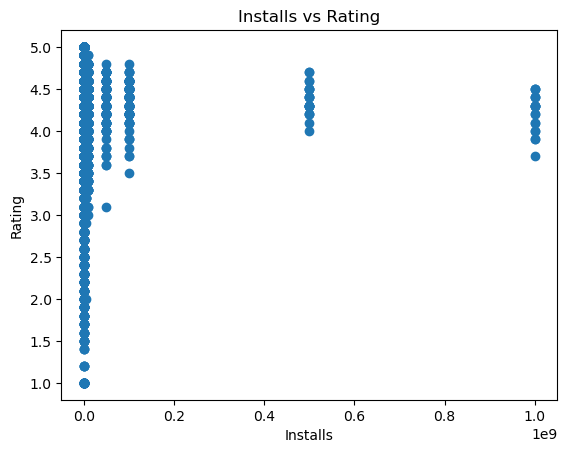

In [21]:
#3.metrics analysis
print(apps[['Rating','Size','Installs','Price']].describe())

#top rated apps
top_apps=apps.sort_values(by='Rating',ascending=False).head(10)
print(top_apps[['App','Rating']])

#correlation
print(apps[['Rating','Size','Installs','Price']].corr())

#scatter plot
plt.scatter(apps['Installs'],apps['Rating'])
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")
plt.show()



Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


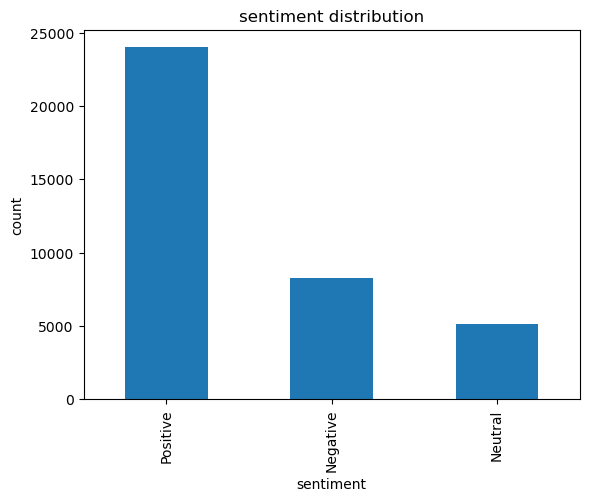

In [23]:
#4.sentiment analysis(user_review.csv)
reviews.dropna(inplace=True)

#sentiment count
sentiment_counts=reviews['Sentiment'].value_counts()
print(sentiment_counts)

#plot
sentiment_counts.plot(kind='bar')
plt.title("sentiment distribution")
plt.xlabel("sentiment")
plt.ylabel("count")
plt.show()

In [24]:
#5.combine both datasets
merged=pd.merge(apps,reviews,on='App',how='inner')

print(merged.head())

   Unnamed: 0                  App        Category  Rating  Reviews  Size  \
0           1  Coloring book moana  ART_AND_DESIGN     3.9      967   NaN   
1           1  Coloring book moana  ART_AND_DESIGN     3.9      967   NaN   
2           1  Coloring book moana  ART_AND_DESIGN     3.9      967   NaN   
3           1  Coloring book moana  ART_AND_DESIGN     3.9      967   NaN   
4           1  Coloring book moana  ART_AND_DESIGN     3.9      967   NaN   

   Installs  Type Price Content Rating                     Genres  \
0    500000  Free     0       Everyone  Art & Design;Pretend Play   
1    500000  Free     0       Everyone  Art & Design;Pretend Play   
2    500000  Free     0       Everyone  Art & Design;Pretend Play   
3    500000  Free     0       Everyone  Art & Design;Pretend Play   
4    500000  Free     0       Everyone  Art & Design;Pretend Play   

       Last Updated Current Ver   Android Ver  price  \
0  January 15, 2018       2.0.0  4.0.3 and up    0.0   
1  January

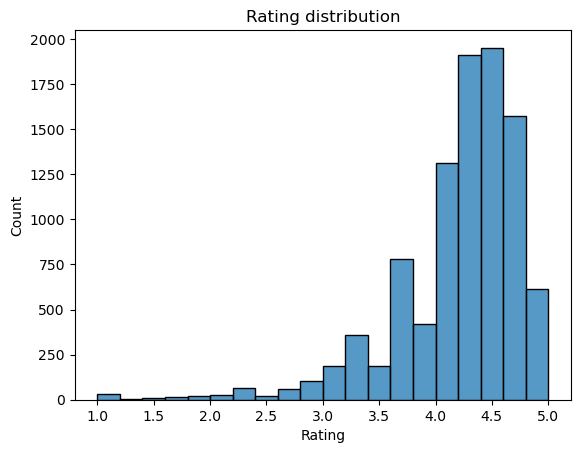

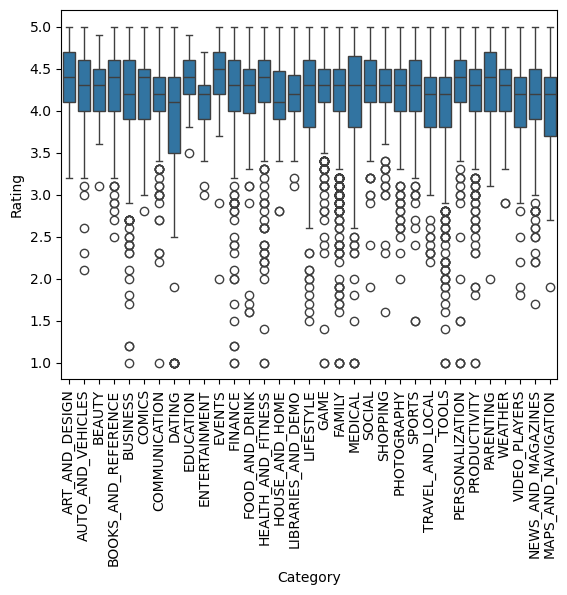

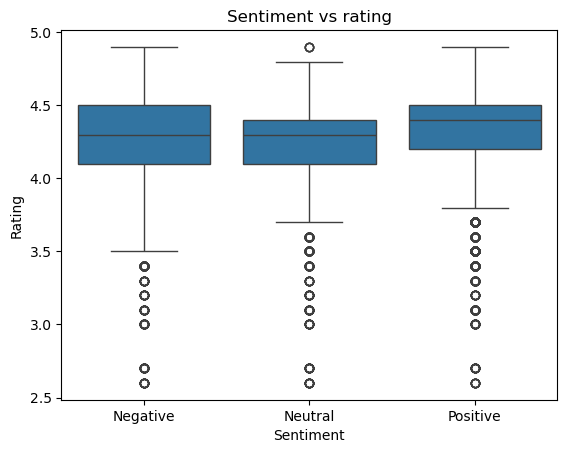

In [29]:
#6.advamced visulization
import seaborn as sns

#rating distribution
sns.histplot(apps['Rating'],bins=20)
plt.title("Rating distribution")
plt.show()

#category vs rating
sns.boxplot(x='Category',y='Rating',data=apps)
plt.xticks(rotation=90)
plt.show()

#sentiment vs rating
sns.boxplot(x='Sentiment',y='Rating',data=merged)
plt.title("Sentiment vs rating")
plt.show()
